# 🧪 Clinical Data Quality Control — Multi-Center Demo

**Objective**: Demonstrate automated QC and harmonization of heterogeneous
multi-center clinical datasets, typical of real-world oncology trials.

**Simulated scenario**: 3 hospital sites (Paris, New York, Berlin) each
submit clinical data with site-specific conventions, errors, and missing values.

**Pipeline**:
1. Generate synthetic multi-center data with realistic quality issues
2. Run automated QC checks to detect all issues
3. Harmonize the data into a unified format
4. Re-run QC to verify corrections

**Author**: Zahia Yanes — Health Data & AI Engineer

In [1]:
# === Imports and configuration ===
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path setup
project_root = os.path.expanduser(
    "~/github-portfolio/clinical-data-qc-toolkit"
)
sys.path.insert(0, os.path.join(project_root, "src"))
figures_dir = os.path.join(project_root, "outputs", "figures")
os.makedirs(figures_dir, exist_ok=True)

from data_simulator import generate_all_sites
from qc_checks import run_all_checks
from harmonizer import harmonize

# Plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 150

SITE_COLORS = {"Site_A": "#3498db", "Site_B": "#e74c3c", "Site_C": "#2ecc71"}

print("✅ Setup complete")

✅ Setup complete


## 1. Generate Multi-Center Data

Simulating 3 clinical sites with different conventions:

| Site | Location | Date Format | Units | Gender Coding | Stage Coding |
|------|----------|-------------|-------|---------------|--------------|
| A | Paris | DD/MM/YYYY | kg, cm | M/F | I, II, III, IV |
| B | New York | MM/DD/YYYY | lbs, in | Male/Female | 1, 2, 3, 4 |
| C | Berlin | YYYY-MM-DD | kg, cm | m/f | Stage I, Stage II... |

In [2]:
# === Generate raw data ===
df_raw = generate_all_sites()
print(f"\n📋 Shape: {df_raw.shape}")
print(f"\n📋 Sample from each site:")
for site in ["Site_A", "Site_B", "Site_C"]:
    print(f"\n--- {site} ---")
    print(df_raw[df_raw["site"] == site].head(3).to_string(index=False))

🏥 Generating Site A (Paris)... 80 patients
🏥 Generating Site B (New York)... 63 patients (including duplicates)
🏥 Generating Site C (Berlin)... 40 patients

📊 Total records: 183
📊 Expected unique patients: 180
📊 Actual records: 183 (duplicates included)

📋 Shape: (183, 15)

📋 Sample from each site:

--- Site_A ---
 patient_id   site  age gender enrollment_date tumor_stage  weight weight_unit  height height_unit  hemoglobin  creatinine   ldh    treatment  death
SITE_A_0001 Site_A   67      F      05/04/2022          IV    96.5          kg   155.5          cm        10.6       12.78 183.0 Atezolizumab      1
SITE_A_0002 Site_A   60      M      29/08/2022          IV    50.5          kg   155.9          cm        13.9        0.74 152.0    Nivolumab      1
SITE_A_0003 Site_A   69      M      26/10/2022         III    65.4          kg   162.8          cm        14.6        1.01 286.0    Nivolumab      1

--- Site_B ---
 patient_id   site  age gender enrollment_date tumor_stage  weight weigh

## 2. Data Quality Issues — Before Harmonization

### 2.1 Visual inspection of cross-site inconsistencies

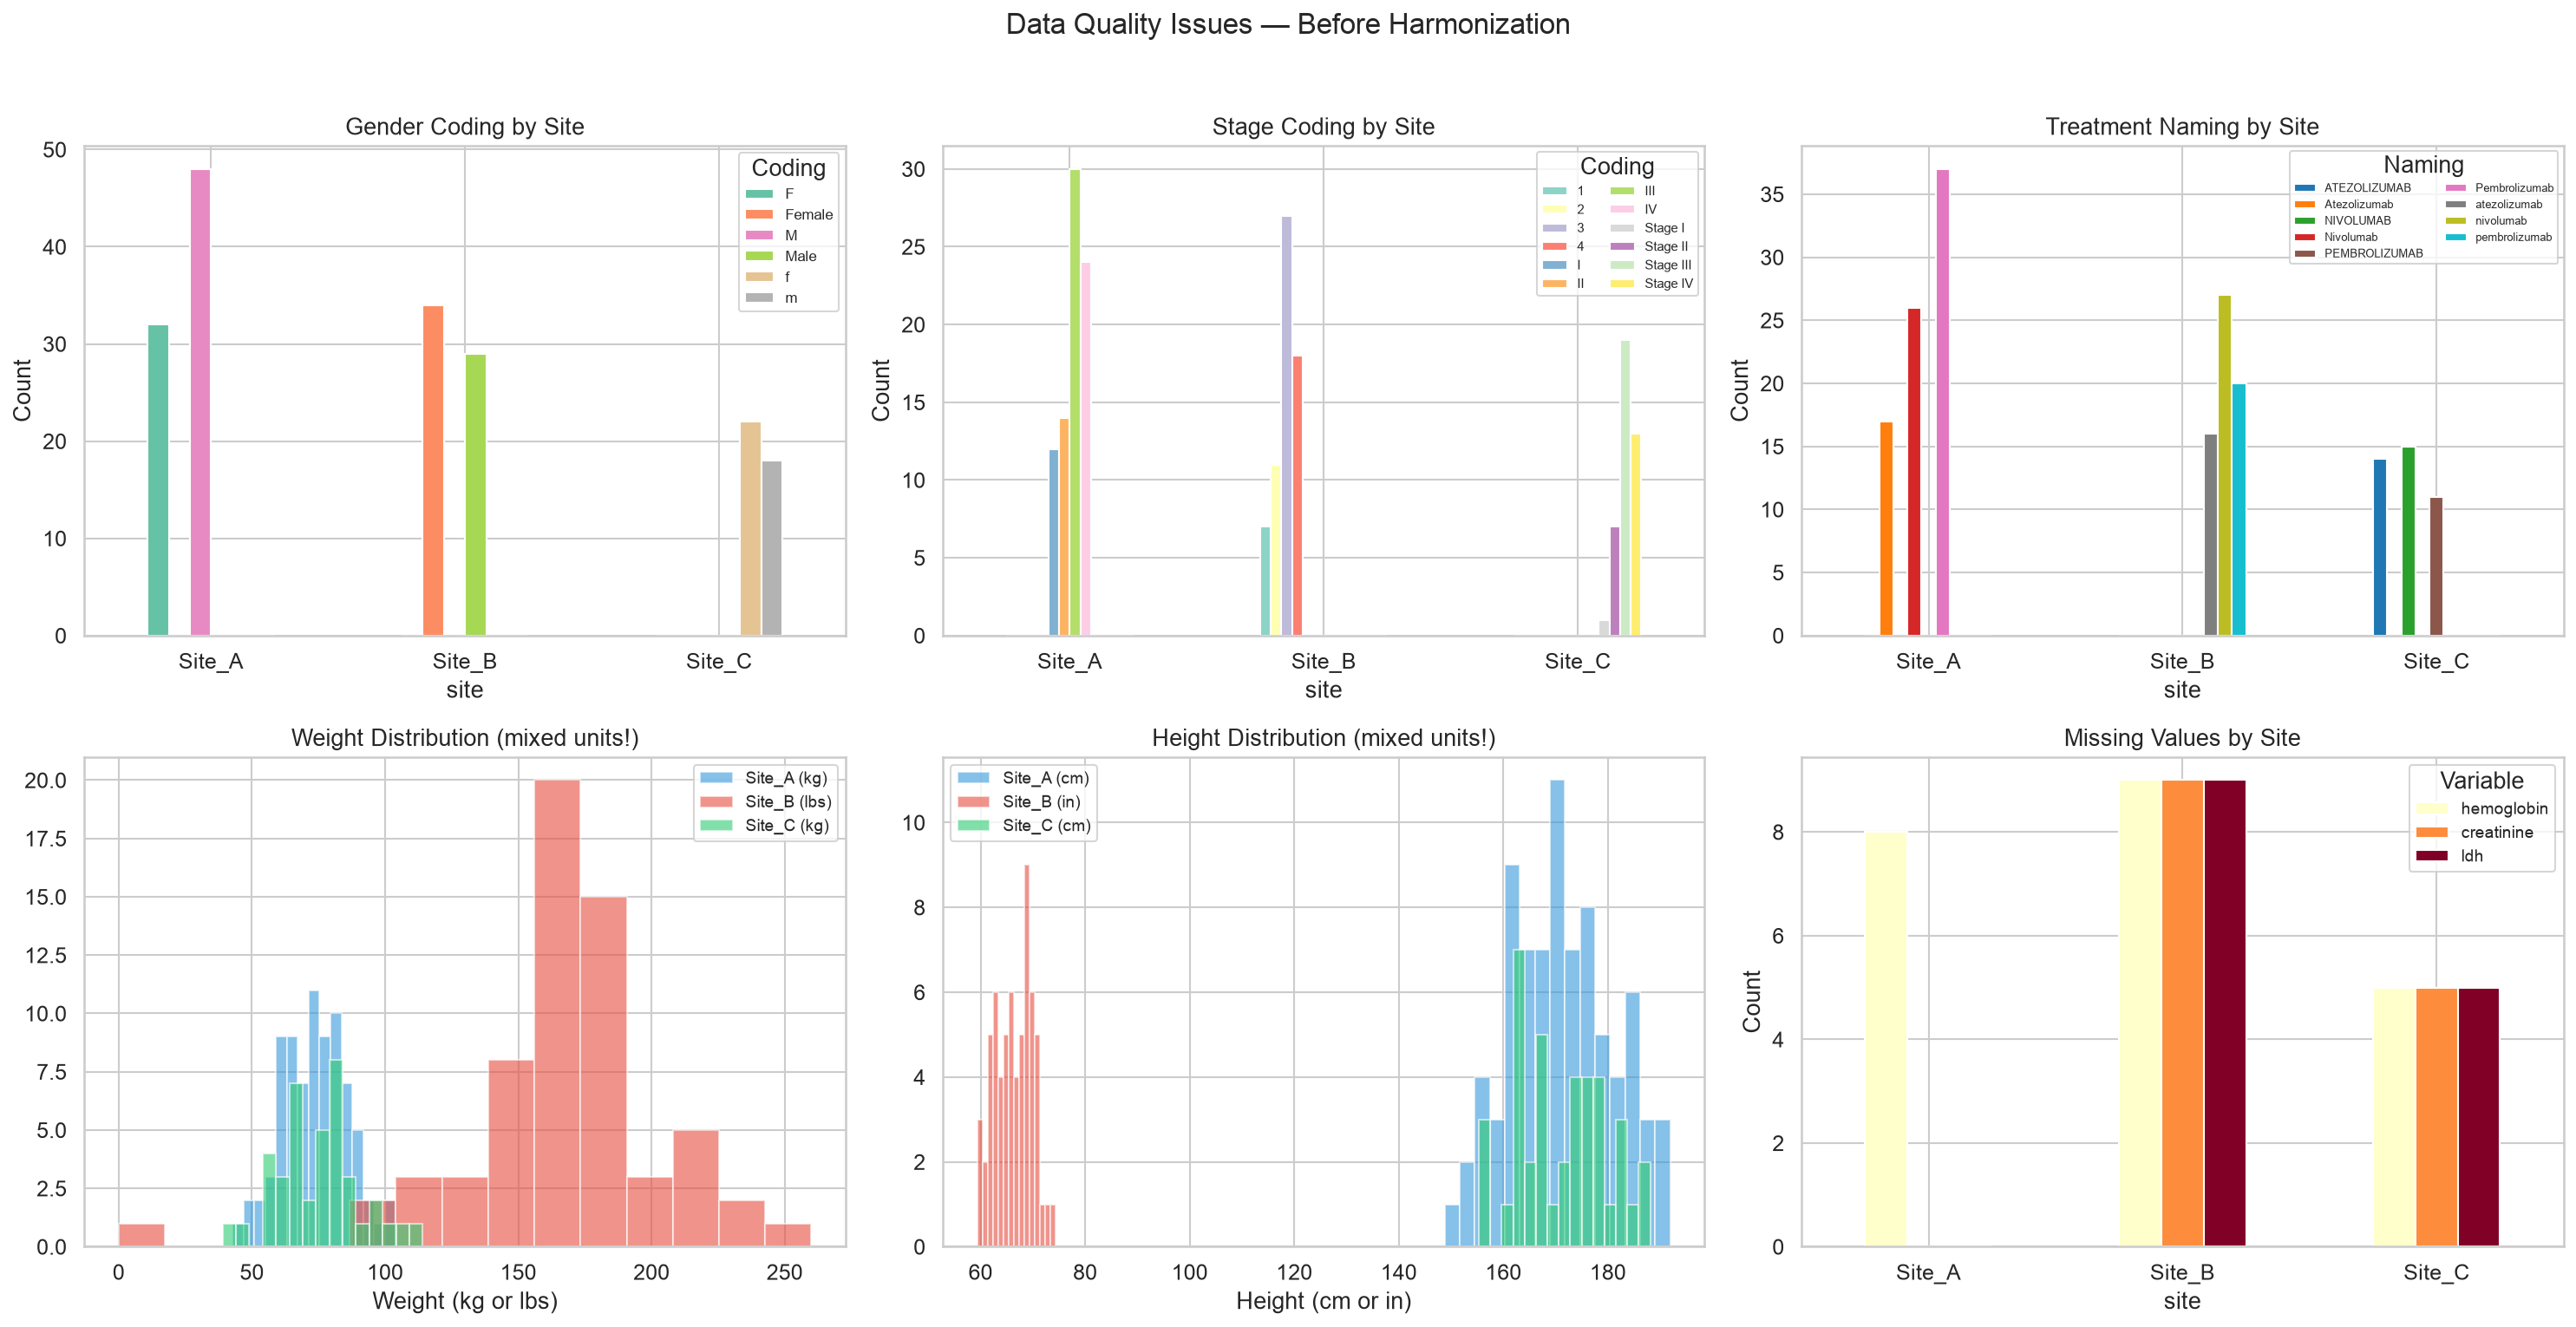

✅ Figure saved


In [3]:
# === Visualize cross-site inconsistencies ===
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# --- Row 1: Categorical inconsistencies ---

# Gender coding per site
gender_data = df_raw.groupby(["site", "gender"]).size().unstack(fill_value=0)
gender_data.plot(kind="bar", ax=axes[0, 0], colormap="Set2", edgecolor="white", rot=0)
axes[0, 0].set_title("Gender Coding by Site")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend(title="Coding", fontsize=8)

# Stage coding per site
stage_data = df_raw.groupby(["site", "tumor_stage"]).size().unstack(fill_value=0)
stage_data.plot(kind="bar", ax=axes[0, 1], colormap="Set3", edgecolor="white", rot=0)
axes[0, 1].set_title("Stage Coding by Site")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend(title="Coding", fontsize=7, ncol=2)

# Treatment naming per site
treat_data = df_raw.groupby(["site", "treatment"]).size().unstack(fill_value=0)
treat_data.plot(kind="bar", ax=axes[0, 2], colormap="tab10", edgecolor="white", rot=0)
axes[0, 2].set_title("Treatment Naming by Site")
axes[0, 2].set_ylabel("Count")
axes[0, 2].legend(title="Naming", fontsize=6, ncol=2)

# --- Row 2: Numerical inconsistencies ---

# Weight distribution (different units!)
for site, color in SITE_COLORS.items():
    subset = df_raw[df_raw["site"] == site]
    unit = subset["weight_unit"].iloc[0]
    axes[1, 0].hist(subset["weight"].dropna(), bins=15, alpha=0.6,
                     color=color, label=f"{site} ({unit})", edgecolor="white")
axes[1, 0].set_title("Weight Distribution (mixed units!)")
axes[1, 0].set_xlabel("Weight (kg or lbs)")
axes[1, 0].legend(fontsize=9)

# Height distribution (different units!)
for site, color in SITE_COLORS.items():
    subset = df_raw[df_raw["site"] == site]
    unit = subset["height_unit"].iloc[0]
    axes[1, 1].hist(subset["height"].dropna(), bins=15, alpha=0.6,
                     color=color, label=f"{site} ({unit})", edgecolor="white")
axes[1, 1].set_title("Height Distribution (mixed units!)")
axes[1, 1].set_xlabel("Height (cm or in)")
axes[1, 1].legend(fontsize=9)

# Missing data per site
missing_by_site = df_raw.groupby("site")[["hemoglobin", "creatinine", "ldh"]].apply(
    lambda x: x.isnull().sum()
)
missing_by_site.plot(kind="bar", ax=axes[1, 2], colormap="YlOrRd",
                     edgecolor="white", rot=0)
axes[1, 2].set_title("Missing Values by Site")
axes[1, 2].set_ylabel("Count")
axes[1, 2].legend(title="Variable", fontsize=9)

plt.suptitle("Data Quality Issues — Before Harmonization", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "01_issues_before.png"), bbox_inches="tight")
plt.show()
print("✅ Figure saved")

### 2.2 Automated QC Report

In [4]:
# === Run automated QC checks ===
report_before = run_all_checks(df_raw, "Raw multi-center data")

🔍 Running quality control checks...

  1/6 Checking missing values...
  2/6 Checking duplicates...
  3/6 Checking value ranges...
  4/6 Checking dates...
  5/6 Checking categorical consistency...
  6/6 Checking unit consistency...

  QUALITY CONTROL REPORT — Raw multi-center data
  Records scanned:  183
  Variables:        15
  Issues found:     14
    🔴 CRITICAL:    7
    🟡 WARNING:     7
    🔵 INFO:        0

  🟡 [WARNING] Missing values: hemoglobin
     Affected: 22 records
     Details: 22 missing values (12.0%) in column 'hemoglobin'
     IDs: ['SITE_A_0006', 'SITE_A_0011', 'SITE_A_0027', 'SITE_A_0052', 'SITE_A_0062'] ... (+17 more)

  🟡 [WARNING] Missing values: creatinine
     Affected: 14 records
     Details: 14 missing values (7.7%) in column 'creatinine'
     IDs: ['SITE_B_0005', 'SITE_B_0011', 'SITE_B_0023', 'SITE_B_0024', 'SITE_B_0025'] ... (+9 more)

  🟡 [WARNING] Missing values: ldh
     Affected: 14 records
     Details: 14 missing values (7.7%) in column 'ldh'
     IDs

## 3. Harmonization

Applying automated corrections:
1. Remove duplicate records
2. Fix impossible values (negative age, zero weight)
3. Standardize dates → ISO format (YYYY-MM-DD)
4. Flag future dates for manual review
5. Harmonize gender → M/F
6. Harmonize tumor stage → I/II/III/IV
7. Harmonize treatment names → Title Case
8. Convert units → metric (kg, cm)

In [5]:
# === Harmonize ===
df_clean, harm_log = harmonize(df_raw)

🔧 Running harmonization pipeline...


✅ Harmonization complete: 183 → 180 records

  HARMONIZATION LOG
  Total steps: 8

  Step 1: Remove duplicates
    Affected: 3 records
    Details: Removed 3 duplicate records based on ['patient_id']

  Step 2: Fix impossible values
    Affected: 3 records
    Details: Set 3 impossible values to NaN (negative age/weight/creatinine)

  Step 3: Standardize dates
    Affected: 180 records
    Details: Converted 180 dates to ISO format (YYYY-MM-DD)

  Step 4: Flag future dates
    Affected: 0 records
    Details: Flagged 0 records with enrollment dates in the future

  Step 5: Standardize gender
    Affected: 180 records
    Details: Harmonized 6 gender codings to 2 (M/F)

  Step 6: Standardize tumor stage
    Affected: 180 records
    Details: Harmonized 12 stage codings to 4 (I/II/III/IV)

  Step 7: Standardize treatment names
    Affected: 180 records
    Details: Harmonized 9 treatment names to 3 (title case)

  Step 8: Convert units to metric
    

## 4. QC After Harmonization

Re-running the same checks to verify corrections.

In [6]:
# === Re-run QC ===
report_after = run_all_checks(df_clean, "Harmonized data")

🔍 Running quality control checks...

  1/6 Checking missing values...
  2/6 Checking duplicates...
  3/6 Checking value ranges...
  4/6 Checking dates...
  5/6 Checking categorical consistency...
  6/6 Checking unit consistency...

  QUALITY CONTROL REPORT — Harmonized data
  Records scanned:  180
  Variables:        16
  Issues found:     7
    🔴 CRITICAL:    1
    🟡 WARNING:     4
    🔵 INFO:        2

  🔵 [INFO] Missing values: age
     Affected: 1 records
     Details: 1 missing values (0.6%) in column 'age'
     IDs: ['SITE_B_0001']

  🔵 [INFO] Missing values: weight
     Affected: 1 records
     Details: 1 missing values (0.6%) in column 'weight'
     IDs: ['SITE_B_0006']

  🟡 [WARNING] Missing values: hemoglobin
     Affected: 22 records
     Details: 22 missing values (12.2%) in column 'hemoglobin'
     IDs: ['SITE_A_0006', 'SITE_A_0011', 'SITE_A_0027', 'SITE_A_0052', 'SITE_A_0062'] ... (+17 more)

  🟡 [WARNING] Missing values: creatinine
     Affected: 15 records
     Details:

## 5. Before vs After Comparison

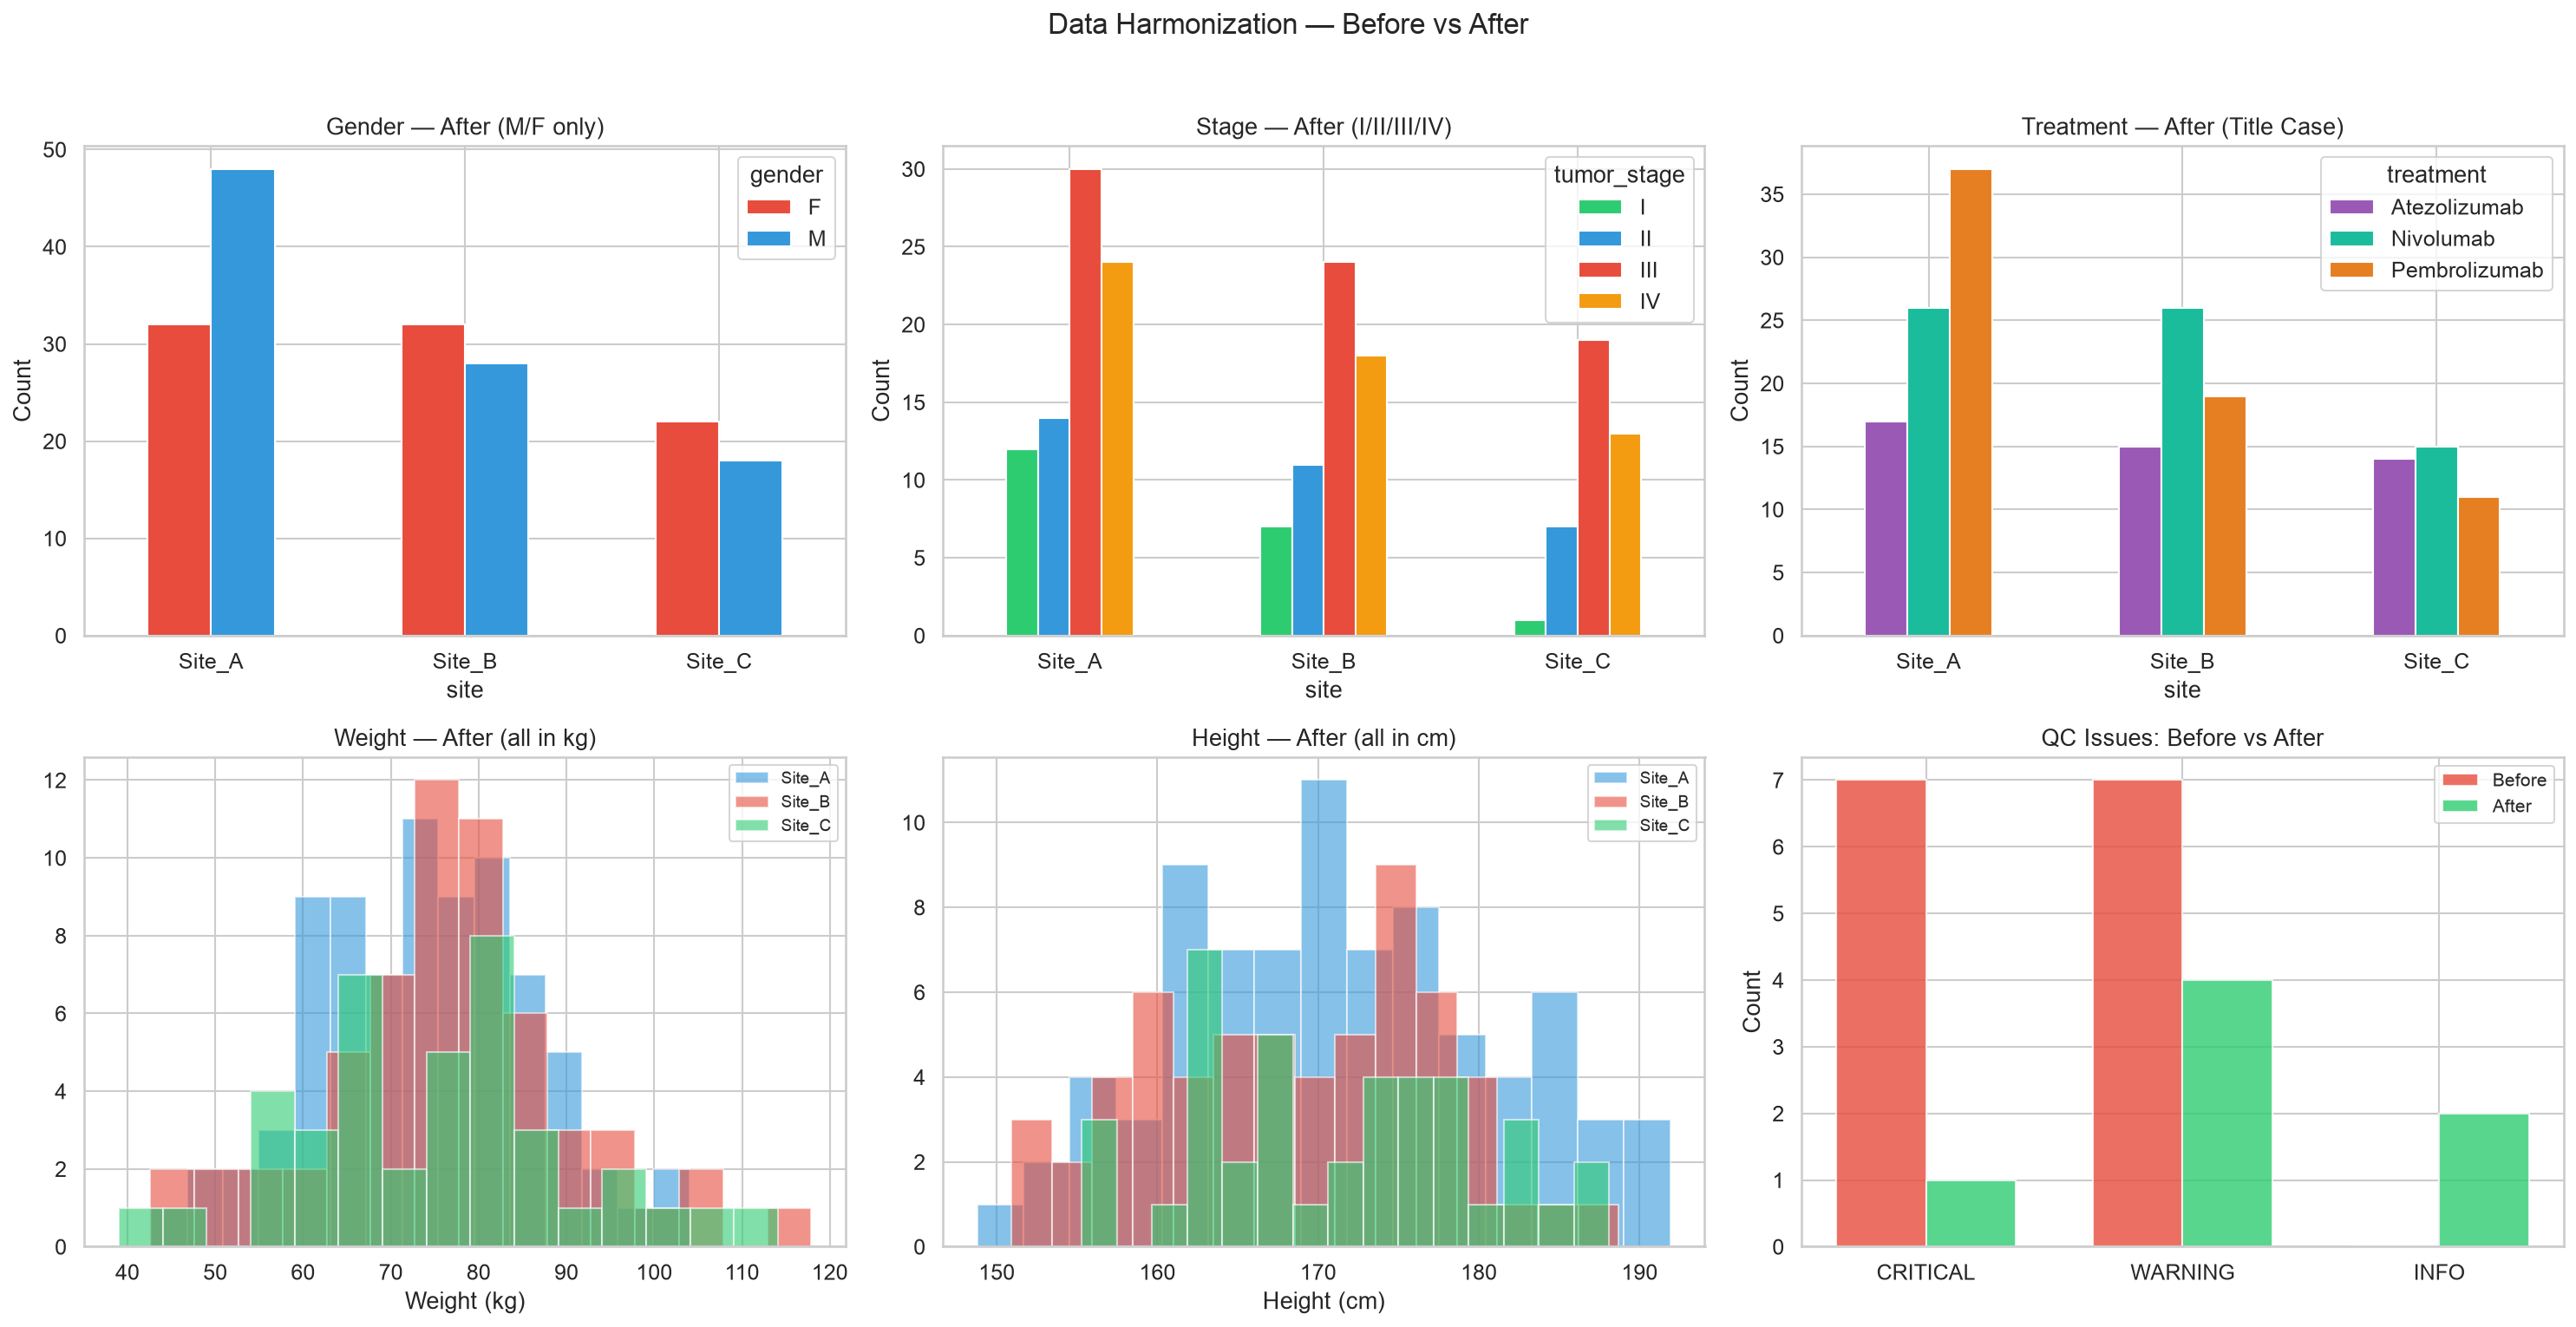

✅ Figure saved


In [7]:
# === Before vs After comparison ===
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# --- Row 1: After harmonization ---

# Gender — now unified
gender_clean = df_clean.groupby(["site", "gender"]).size().unstack(fill_value=0)
gender_clean.plot(kind="bar", ax=axes[0, 0], color=["#e74c3c", "#3498db"],
                  edgecolor="white", rot=0)
axes[0, 0].set_title("Gender — After (M/F only)")
axes[0, 0].set_ylabel("Count")

# Stage — now unified
stage_clean = df_clean.groupby(["site", "tumor_stage"]).size().unstack(fill_value=0)
stage_clean.plot(kind="bar", ax=axes[0, 1], color=["#2ecc71", "#3498db", "#e74c3c", "#f39c12"],
                 edgecolor="white", rot=0)
axes[0, 1].set_title("Stage — After (I/II/III/IV)")
axes[0, 1].set_ylabel("Count")

# Treatment — now unified
treat_clean = df_clean.groupby(["site", "treatment"]).size().unstack(fill_value=0)
treat_clean.plot(kind="bar", ax=axes[0, 2], color=["#9b59b6", "#1abc9c", "#e67e22"],
                 edgecolor="white", rot=0)
axes[0, 2].set_title("Treatment — After (Title Case)")
axes[0, 2].set_ylabel("Count")

# --- Row 2: Numerical after conversion ---

# Weight — all in kg now
for site, color in SITE_COLORS.items():
    subset = df_clean[df_clean["site"] == site]
    axes[1, 0].hist(subset["weight"].dropna(), bins=15, alpha=0.6,
                     color=color, label=site, edgecolor="white")
axes[1, 0].set_title("Weight — After (all in kg)")
axes[1, 0].set_xlabel("Weight (kg)")
axes[1, 0].legend(fontsize=9)

# Height — all in cm now
for site, color in SITE_COLORS.items():
    subset = df_clean[df_clean["site"] == site]
    axes[1, 1].hist(subset["height"].dropna(), bins=15, alpha=0.6,
                     color=color, label=site, edgecolor="white")
axes[1, 1].set_title("Height — After (all in cm)")
axes[1, 1].set_xlabel("Height (cm)")
axes[1, 1].legend(fontsize=9)

# QC issues comparison
categories = ["CRITICAL", "WARNING", "INFO"]
before_counts = [
    len([i for i in report_before.issues if i["severity"] == s])
    for s in categories
]
after_counts = [
    len([i for i in report_after.issues if i["severity"] == s])
    for s in categories
]

x = np.arange(len(categories))
width = 0.35
axes[1, 2].bar(x - width/2, before_counts, width, label="Before",
               color="#e74c3c", edgecolor="white", alpha=0.8)
axes[1, 2].bar(x + width/2, after_counts, width, label="After",
               color="#2ecc71", edgecolor="white", alpha=0.8)
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(categories)
axes[1, 2].set_title("QC Issues: Before vs After")
axes[1, 2].set_ylabel("Count")
axes[1, 2].legend(fontsize=10)

plt.suptitle("Data Harmonization — Before vs After", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "02_before_vs_after.png"), bbox_inches="tight")
plt.show()
print("✅ Figure saved")

In [8]:
# === Summary statistics ===
print("📊 Dataset comparison:")
print(f"{'':30} {'Before':>10} {'After':>10}")
print(f"{'-'*52}")
print(f"{'Records':30} {len(df_raw):>10} {len(df_clean):>10}")
print(f"{'Unique patients':30} {df_raw['patient_id'].nunique():>10} {df_clean['patient_id'].nunique():>10}")
print(f"{'Gender codings':30} {df_raw['gender'].nunique():>10} {df_clean['gender'].nunique():>10}")
print(f"{'Stage codings':30} {df_raw['tumor_stage'].nunique():>10} {df_clean['tumor_stage'].nunique():>10}")
print(f"{'Treatment names':30} {df_raw['treatment'].nunique():>10} {df_clean['treatment'].nunique():>10}")
print(f"{'Weight units':30} {df_raw['weight_unit'].nunique():>10} {df_clean['weight_unit'].nunique():>10}")
print(f"{'QC issues':30} {len(report_before.issues):>10} {len(report_after.issues):>10}")

📊 Dataset comparison:
                                   Before      After
----------------------------------------------------
Records                               183        180
Unique patients                       180        180
Gender codings                          6          2
Stage codings                          12          4
Treatment names                         9          3
Weight units                            2          1
QC issues                              14          7


## 6. Key Findings

### Issues Resolved
1. **Duplicates**: 3 duplicate records removed
2. **Impossible values**: Negative age, zero weight, negative creatinine → set to NaN
3. **Gender coding**: 6 variants (M/F/Male/Female/m/f) → unified to M/F
4. **Stage coding**: 12 variants → unified to I/II/III/IV
5. **Treatment naming**: 9 variants → unified to 3 (Title Case)
6. **Units**: Imperial (lbs/in) → Metric (kg/cm)
7. **Date formats**: 3 formats → ISO standard (YYYY-MM-DD)

### Remaining Issues (expected)
- **Missing values**: Cannot be fabricated — documented for downstream handling
- **LDH outlier (4.0 U/L)**: Flagged for clinical review
- **Future dates**: Flagged but not removed (requires manual verification)

### Clinical Data Engineering Lessons
- **Never assume consistency** across clinical sites
- **Always validate units** before merging multi-center data
- **Document every transformation** for audit trail compliance
- **Flag, don't delete** uncertain values — clinical review is essential